In [1]:
using ITensors
using ITensorMPS
using PolyChaos
using LinearAlgebra
using Plots
#using Observers #for TDVP
using JLD2
using ProgressMeter
using Kronecker
using SparseArrays

include(dirname(dirname(@__DIR__))*"/src/chain_mapping.jl")
include(dirname(dirname(@__DIR__))*"/src/map_calculations.jl")

Main.map_calculations

Correlation matrix propagator
Calculating Λ(t) from the single particle correlation matrix.


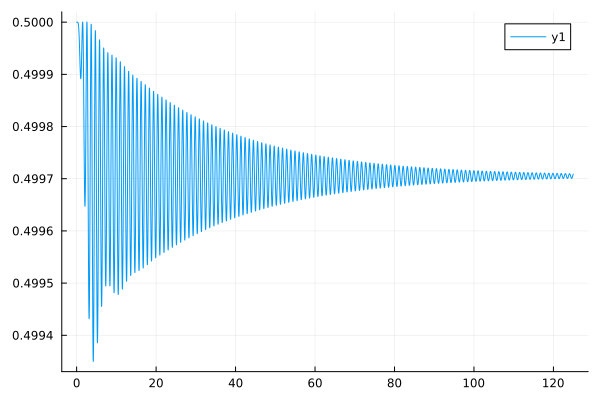

Progress: 100%|█████████████████████████████████████████| Time: 0:00:36


In [ ]:

bath = chain_mapping.BathParameters(Γ = 0.1,β = 1.0,μ = 0,D = 1.0,N = 150,spectral_function="smoothed box")

system = chain_mapping.RingParameters(B = 1,J = 1,N_ring = 3,occupations=[0.2,0.8,0.1], compute_maps_bool = true)

symmetry_subspace = "Full"#"Number conserving"

Hsingle,initial_correlation_matrix,sys_anc_inds,system_inds,ancilla_inds = chain_mapping.build_thermofield_ring_model(bath,system);

#evolution parameters
δt = 0.01
T = 10
times = range(δt,stop=T,step=δt)
site = 1

println("Correlation matrix propagator")
corrs = map_calculations.propagate_correlations(initial_correlation_matrix,Hsingle,times)
den = [corr[site,site] for corr in corrs]
display(Plots.plot(times,real.(den)))

println("Markovian evolution")
L_markovian = fermionic_spin_ring_lindblad(bath,system)
ρi = map_calculations.calculate_ρ_from_correlation_matrix(initial_correlation_matrix,system_inds; eps=1e-14)
ρi = map_calculations.vectorise_mat(ρi)
ρ_markovian_vec = markovian_evolution(L_markovian,ρ_init,times)
den_markovian = [tr(number_operator(site,system.N_ring)*map_calculations.unvectorise_ρ(ρ,true)) for ρ in ρ_markovian_vec]

plot(times,real.(den),label="Exact")
display(plot!(times,real.(den_markovian),label="Markovian"))

if system.compute_maps_bool
    Λ_vec,L_vec = map_calculations.compute_maps(corrs,δt,sys_anc_inds,ancilla_inds;symmetry_subspace=symmetry_subspace)
    spectra_Λ,spectra_L = map_calculations.compute_spectra(Λ_vec,L_vec)
    propagator_steadystates  = [map_calculations.NESS_extraction(L,"L",system.N_ring;symmetry_subspace=symmetry_subspace) for L in L_vec]
    map_steadystates = [map_calculations.NESS_extraction(Λ,"Λ",system.N_ring;symmetry_subspace=symmetry_subspace) for Λ in Λ_vec]

    dLdt = map_calculations.differentiate(L_vec,δt)

    #map check
    ρi = map_calculations.calculate_ρ_from_correlation_matrix(initial_correlation_matrix,system_inds; eps=1e-14)
    ρ_evolved = map_calculations.calculate_ρ_from_correlation_matrix(corrs[end],system_inds; eps=1e-14)
    if symmetry_subspace =="Number conserving"
        @show(norm(map_calculations.expand_Λ(Λ_vec[end],system.N_ring)*map_calculations.vectorise_mat(ρi)-map_calculations.vectorise_mat(ρ_evolved)))
    else
        @show(norm(Λ_vec[end]*map_calculations.vectorise_mat(ρi)-map_calculations.vectorise_mat(ρ_evolved)))

    end
    display(Plots.plot(times,real.(spectra_Λ),label=false,title="Map spectra"))
    display(Plots.plot(times[2:end-1],real.(spectra_L),ms=0.1,label=false,title="propagator spectra"))

    display(plot(times[3:end-2],norm.(dLdt),label="|dL/dt|"))
end

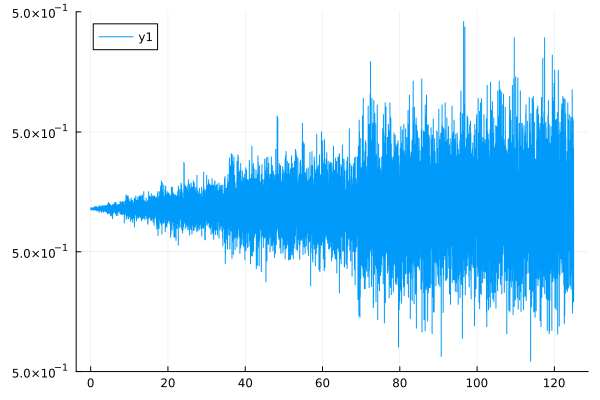

In [139]:

function fermionic_spin_ring_lindblad(bath,system)

    d = 2^system.N_ring
    Id = 1* Matrix(I, d, d)
    Left_vac = map_calculations.vectorise_mat(Id)
    cdag,c = map_calculations.matrix_operators(system.N_ring)

    Hsys = complex(zeros(d,d))

    for i =1:system.N_ring
        Hsys += 2*system.B*cdag[i]*c[i]
        if i <system.N_ring
            Hsys += 2*system.J*cdag[i]*c[i+1]
            Hsys += 2*system.J*cdag[i+1]*c[i]

        elseif i!= 1
            @assert(i==system.N_ring)
           # Hsys[1,i] = 2*system.J
           # Hsys[i,1] = 2*system.J
            Hsys += 2*system.J*cdag[1]*c[i]
            Hsys += 2*system.J*cdag[i]*c[1]
        end
    end


    L_unitary = -im*(map_calculations.rmult(Hsys)- map_calculations.lmult(Hsys))

    Γd = (4/π)*bath.Γ*(1-chain_mapping.fermi_factor(Hsys[1,1],bath.β,bath.μ))
    Γe = (4/π)*bath.Γ*chain_mapping.fermi_factor(Hsys[1,1],bath.β,bath.μ)

    ind = 3
    emission = Γd*(map_calculations.rmult(cdag[ind])*map_calculations.lmult(c[ind]) - (1/2)*map_calculations.rmult(cdag[ind]*c[ind]) - (1/2)*map_calculations.lmult(cdag[ind]*c[ind]))
    absorption = Γe*(map_calculations.rmult(c[ind])*map_calculations.lmult(cdag[ind]) - (1/2)*map_calculations.rmult(c[ind]*cdag[ind]) - (1/2)*map_calculations.lmult(c[ind]*cdag[ind]))
    L_markovian =L_unitary + absorption + emission

    return L_markovian
end
function markovian_evolution(L,ρi,times)
    return [exp(L*t)*ρi for t in times]
end
function number_operator(ind,Nsys)
    N = [0 0;0 1]
    Id = Matrix(I,2,2)

    if ind == 1
        N_manybody = N
    else
        N_manybody = Id
    end

    for i=1:Nsys-1
        if i+1 == ind
            N_manybody = kronecker(N_manybody,N)
        else
            N_manybody = kronecker(N_manybody,Id)
        end
    end
    return N_manybody
end

L_markovian = fermionic_spin_ring_lindblad(bath,system)

ρ_init = Matrix(I,2^system.N_ring,2^system.N_ring)
ρ_init = ρ_init/(tr(ρ_init))
ρ_init = map_calculations.vectorise_mat(ρ_init)


ρ_markovian_vec = markovian_evolution(L_markovian,ρ_init,times)
first_mode_occ = [tr(number_operator(1,system.N_ring)*map_calculations.unvectorise_ρ(ρ,true)) for ρ in ρ_markovian_vec]

plot(times,real.(first_mode_occ))

In [5]:

# anim = @animate for i=1:length(times)
#     Plots.scatter(real.(spectra_Λ[i,:]),imag.(spectra_Λ[i,:]),
#     xlim=(-1,1),ylim=(-1,1),
#     xlabel = "Re",
#     ylabel = "Im",label = "",ms=2)
# end
# gif(anim,"map spectrum1.gif")


# anim = @animate for i=1:length(times)-2
#     Plots.scatter(real.(spectra_L[i,:]),imag.(spectra_L[i,:]),
#     xlim=(-0.25,0.02),
#     xlabel = "Re",
#     ylabel = "Im",label = "",ms=2)
# end
# gif(anim,"propagator spectrum2.gif")